# Fama-French 5 Factor model

In [112]:
# !pip install pandas_ta
# !pip install --upgrade numpy pandas_ta

In [13]:
from statsmodels.regression.rolling import RollingOLS
import pandas_datareader.data as web
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns
import pandas as pd
import numpy as np
import datetime as dt
import yfinance as yf
import pandas_ta
import warnings
warnings.filterwarnings('ignore')
import statsmodels.formula.api as smf


## Data Processing

In [91]:
sp500 = pd.read_html('https://en.wikipedia.org/wiki/List_of_S%26P_500_companies')[0]

sp500['Symbol'] = sp500['Symbol'].str.replace('.', '-')

symbols_list = sp500['Symbol'].unique().tolist()
symbols_list.append('^GSPC')
# start_date = '2024-04-01'
end_date = '2024-12-31'

start_date = pd.to_datetime(end_date)-pd.DateOffset(365*5)

df = yf.download(tickers=symbols_list,
                 start=start_date,
                 end=end_date,auto_adjust =False).stack()

df.index.names = ['date', 'ticker']

df.columns = df.columns.str.lower()
df.head()

[*********************100%***********************]  504 of 504 completed


Price              adj close      close       high        low       open  \
date       ticker                                                          
2020-01-02 A       82.885246  85.949997  86.349998  85.199997  85.900002   
           AAPL    72.716095  75.087502  75.150002  73.797501  74.059998   
           ABBV    71.589790  89.550003  89.570000  88.510002  89.080002   
           ABT     79.273956  86.949997  86.959999  85.800003  86.059998   
           ACGL    41.268997  43.400002  43.400002  42.880001  43.009998   

Price                   volume  
date       ticker               
2020-01-02 A         1410500.0  
           AAPL    135480400.0  
           ABBV      5639200.0  
           ABT       4969000.0  
           ACGL      1376700.0

In [92]:
# Risk-free rate (10-year U.S. Treasury yield as a percentage, e.g., 4.305%)
risk_free_rate = 0.04035/252  # Convert annual rate to daily rate
risk_free_rate

0.0001601190476190476

In [93]:
df2 = df.reset_index()[['date', 'ticker', 'close']]
df2.head()
df2 = df2[(df2['ticker'] == 'NVDA') | (df2['ticker'] == '^GSPC') ]
df2.head()

Price,date,ticker,close
336,2020-01-02,NVDA,5.997750
490,2020-01-02,^GSPC,3257.850098
827,2020-01-03,NVDA,5.901750
981,2020-01-03,^GSPC,3234.850098
1318,2020-01-06,NVDA,5.926500


In [94]:
Stock_close = df2.pivot(index = 'date', columns = 'ticker',values = 'close')
Stock_close = Stock_close.pct_change().dropna()
Stock_close = Stock_close.rename(columns={'^GSPC': 'GSPC'})
Stock_close = Stock_close.reset_index()
Stock_close_capm = Stock_close
Stock_close.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1256 entries, 0 to 1255
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    1256 non-null   datetime64[ns]
 1   NVDA    1256 non-null   float64       
 2   GSPC    1256 non-null   float64       
dtypes: datetime64[ns](1), float64(2)
memory usage: 29.6 KB


In [95]:
Stock_close_capm['exs_rtn_nvda'] = Stock_close_capm['NVDA'] -risk_free_rate

Stock_close_capm['MKT_prm'] = Stock_close_capm['GSPC'] -risk_free_rate
Stock_close_capm = Stock_close_capm[['date','exs_rtn_nvda','MKT_prm']]
Stock_close_capm.head()


ticker,date,exs_rtn_nvda,MKT_prm
0,2020-01-03,-0.016166,-0.007220
1,2020-01-06,0.004034,0.003373
2,2020-01-07,0.011947,-0.002963
3,2020-01-08,0.001715,0.004742
4,2020-01-09,0.010822,0.006495


In [96]:

Stock_close_capm = Stock_close_capm.set_index('date')
Stock_close_capm.info()
Stock_close_capm.head()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1256 entries, 2020-01-03 to 2024-12-30
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   exs_rtn_nvda  1256 non-null   float64
 1   MKT_prm       1256 non-null   float64
dtypes: float64(2)
memory usage: 29.4 KB


ticker,exs_rtn_nvda,MKT_prm
date,,
2020-01-03,-0.016166,-0.007220
2020-01-06,0.004034,0.003373
2020-01-07,0.011947,-0.002963
2020-01-08,0.001715,0.004742
2020-01-09,0.010822,0.006495


In [98]:
# 5 Factor Fama french model
url = 'https://github.com/Amanjhagta/Data-Science/blob/main/Data/fama-french/F-F_Research_Data_5_Factors_2x3_daily.CSV?raw=True'
factor_data = pd.read_csv(url)
factor_data['date'] = pd.to_datetime(factor_data['date'], format='%Y%m%d')
factor_data.head()

,date,Mkt-RF,SMB,HML,RMW,CMA,RF
0,1963-07-01,-0.67,0.02,-0.35,0.03,0.13,0.012
1,1963-07-02,0.79,-0.28,0.28,-0.08,-0.21,0.012
2,1963-07-03,0.63,-0.18,-0.10,0.13,-0.25,0.012
3,1963-07-05,0.40,0.09,-0.28,0.07,-0.30,0.012
4,1963-07-08,-0.63,0.07,-0.20,-0.27,0.06,0.012


In [99]:
Stock_close_FF = pd.merge(Stock_close, factor_data, on="date", how="left")
Stock_close_FF['exs_rtn_nvda'] = Stock_close_FF['NVDA'] - Stock_close_FF['RF']
Stock_close_FF = Stock_close_FF.rename(columns={'Mkt-RF': 'MKT_prmf'})
Stock_close_FF.head()

,date,NVDA,GSPC,exs_rtn_nvda,MKT_prm,MKT_prmf,SMB,HML,RMW,CMA,RF
0,2020-01-03,-0.016006,-0.007060,-0.022006,-0.007220,-0.67,0.30,0.00,-0.13,-0.11,0.006
1,2020-01-06,0.004194,0.003533,-0.001806,0.003373,0.36,-0.21,-0.55,-0.17,-0.26,0.006
2,2020-01-07,0.012107,-0.002803,0.006107,-0.002963,-0.19,-0.03,-0.25,-0.13,-0.24,0.006
3,2020-01-08,0.001876,0.004902,-0.004124,0.004742,0.47,-0.16,-0.66,-0.16,-0.18,0.006
4,2020-01-09,0.010983,0.006655,0.004983,0.006495,0.65,-0.71,-0.48,-0.14,0.04,0.006


In [101]:
Stock_close_FF_fltr = Stock_close_FF[['date','exs_rtn_nvda','MKT_prm','SMB','HML','RMW','CMA']]
# Stock_close_FF_fltr = Stock_close_FF_fltr.rename(columns={'Mkt-RF': 'MKT_prm'})
Stock_close_FF_fltr.head() 

,date,exs_rtn_nvda,MKT_prm,SMB,HML,RMW,CMA
0,2020-01-03,-0.022006,-0.007220,0.30,0.00,-0.13,-0.11
1,2020-01-06,-0.001806,0.003373,-0.21,-0.55,-0.17,-0.26
2,2020-01-07,0.006107,-0.002963,-0.03,-0.25,-0.13,-0.24
3,2020-01-08,-0.004124,0.004742,-0.16,-0.66,-0.16,-0.18
4,2020-01-09,0.004983,0.006495,-0.71,-0.48,-0.14,0.04


In [102]:
Stock_close_FF_fltr.set_index('date')

,exs_rtn_nvda,MKT_prm,SMB,HML,RMW,CMA
date,,,,,,
2020-01-03,-0.022006,-0.007220,0.30,0.00,-0.13,-0.11
2020-01-06,-0.001806,0.003373,-0.21,-0.55,-0.17,-0.26
2020-01-07,0.006107,-0.002963,-0.03,-0.25,-0.13,-0.24
2020-01-08,-0.004124,0.004742,-0.16,-0.66,-0.16,-0.18
2020-01-09,0.004983,0.006495,-0.71,-0.48,-0.14,0.04
...,...,...,...,...,...,...
2024-12-23,0.019897,0.007127,-0.85,-0.19,0.28,0.66
2024-12-24,-0.013062,0.010883,-0.12,-0.05,-0.13,-0.37
2024-12-26,-0.019068,-0.000566,1.09,-0.19,-0.44,0.35


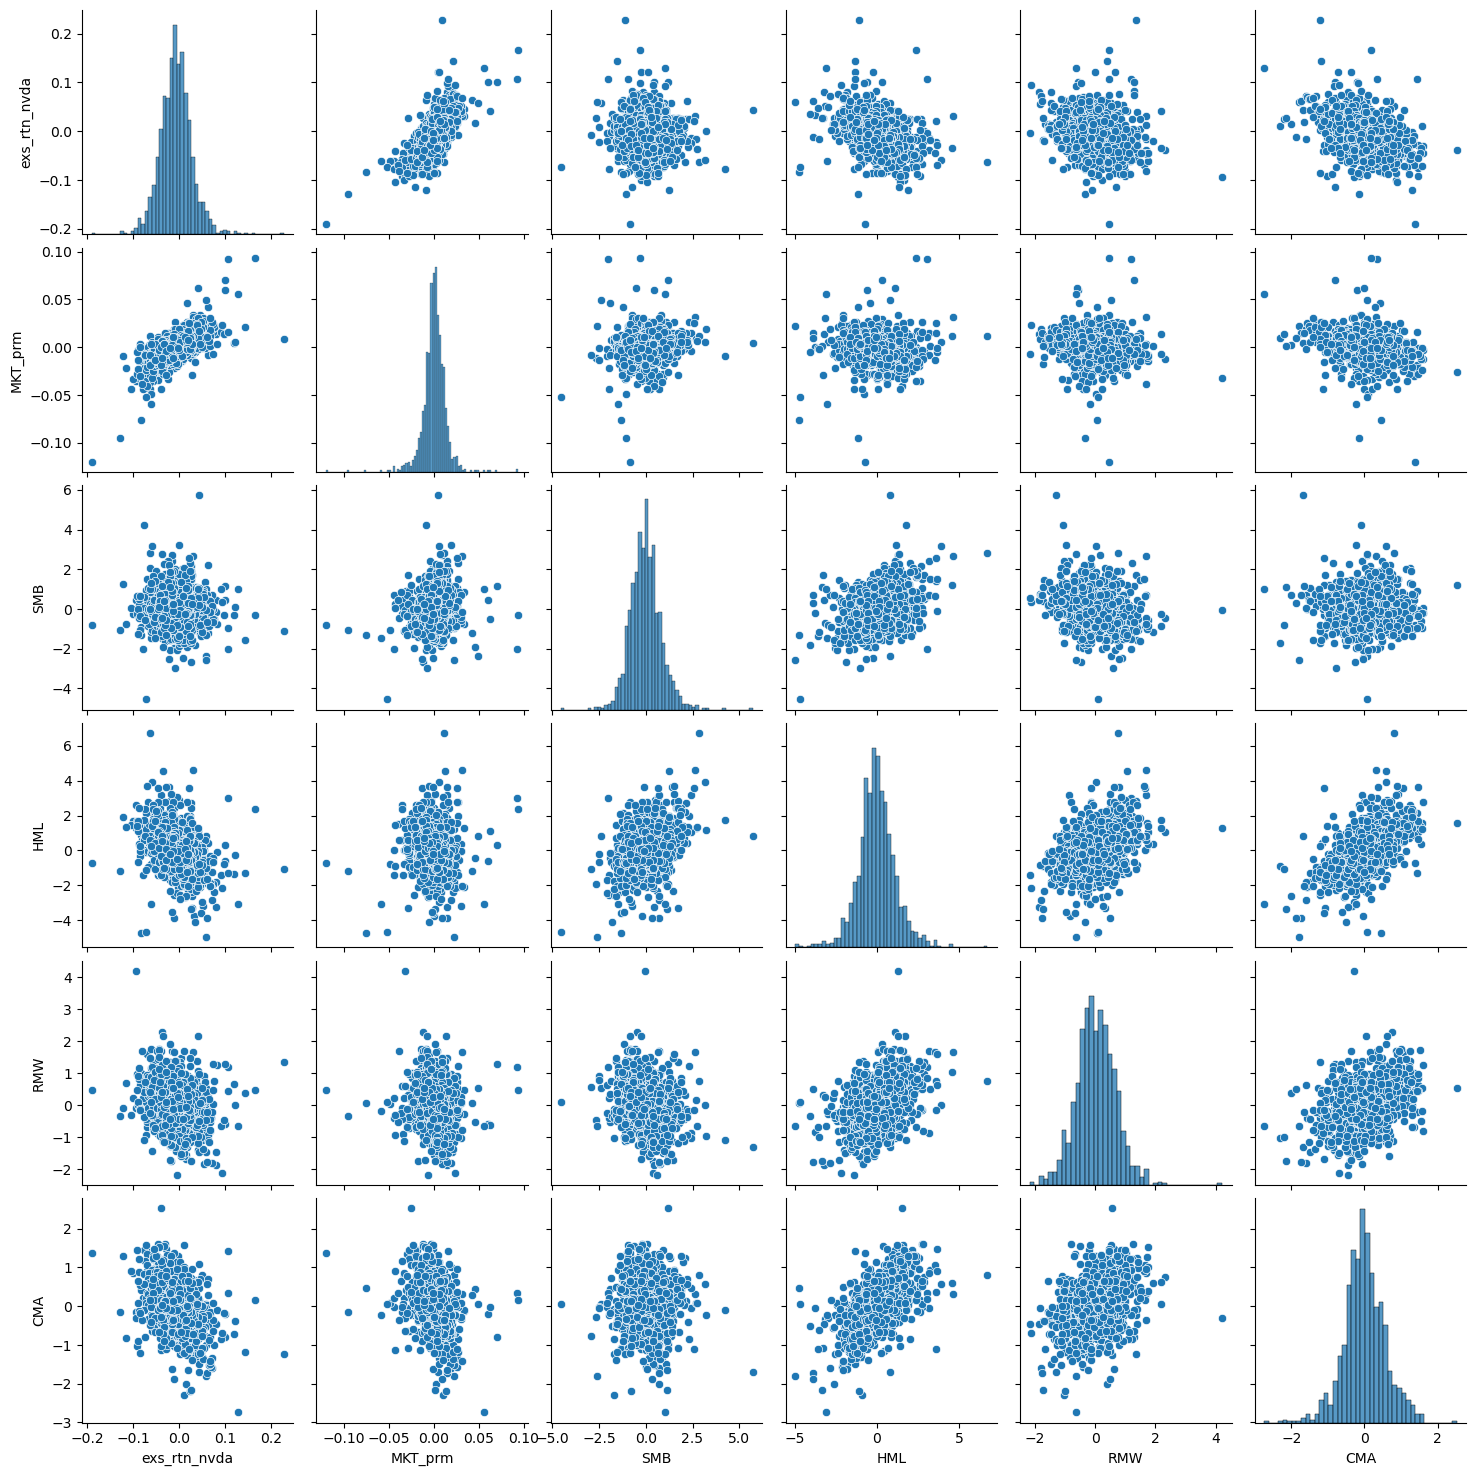

In [77]:
pairplot_ff = sns.pairplot(Stock_close_FF_fltr)
pairplot_ff

# 1. Regression model

In [103]:
# # Fit the regression model
reg_nvda_ff = smf.ols('exs_rtn_nvda ~ MKT_prm+SMB+HML+RMW+CMA', data=Stock_close_FF_fltr).fit()

# # Print the summary
print(reg_nvda_ff.summary())

                            OLS Regression Results                            
Dep. Variable:           exs_rtn_nvda   R-squared:                       0.569
Model:                            OLS   Adj. R-squared:                  0.568
Method:                 Least Squares   F-statistic:                     330.7
Date:                Tue, 15 Apr 2025   Prob (F-statistic):          9.35e-226
Time:                        02:03:25   Log-Likelihood:                 2961.9
No. Observations:                1256   AIC:                            -5912.
Df Residuals:                    1250   BIC:                            -5881.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0069      0.001    -10.676      0.0

# Calculating the expected return

In [104]:
# Extracting coefficients (alpha and betas for each factor)
alpha_ff = reg_nvda_ff.params['Intercept']
beta_market = reg_nvda_ff.params['MKT_prm']
beta_smb = reg_nvda_ff.params['SMB']
beta_hml = reg_nvda_ff.params['HML']
beta_rmw = reg_nvda_ff.params['RMW']
beta_cma = reg_nvda_ff.params['CMA']

# Extract R-squared and Adjusted R-squared
r_squared_ff = reg_nvda_ff.rsquared
adj_r_squared_ff = reg_nvda_ff.rsquared_adj

# Print results
print(f"Alpha (α): {alpha_ff}")
print(f"Beta (Market) (β_MKT): {beta_market}")
print(f"Beta (SMB) (β_SMB): {beta_smb}")
print(f"Beta (HML) (β_HML): {beta_hml}")
print(f"Beta (RMW) (β_RMW): {beta_rmw}")
print(f"Beta (CMA) (β_CMA): {beta_cma}")
print(f"R-squared: {r_squared_ff}")
print(f"Adjusted R-squared: {adj_r_squared_ff}")

# # Optional: Compute expected return based on a given market premium
# market_premium_value_ff = Stock_close_FF_fltr['MKT_prm'].mean() # Example market premium (6%)
# smb_value = Stock_close_FF_fltr['SMB'].mean() # Example SMB factor
# hml_value = Stock_close_FF_fltr['HML'].mean() # Example HML factor
# rmw_value = Stock_close_FF_fltr['RMW'].mean()  # Example RMW factor
# cma_value = Stock_close_FF_fltr['CMA'].mean()  # Example CMA factor

# # Compute expected return using the Fama-French 5-factor model equation
# expected_return_ff = (alpha_ff + 
#                       beta_market * market_premium_value_ff + 
#                       beta_smb * smb_value + 
#                       beta_hml * hml_value + 
#                       beta_rmw * rmw_value+
#                       beta_cma * cma_value)

# print(f"Expected Return (FF5): {expected_return_ff:.4f}")

Alpha (α): -0.006922926368020141
Beta (Market) (β_MKT): 1.6901840615940997
Beta (SMB) (β_SMB): -0.0005197973185619592
Beta (HML) (β_HML): -0.0088944348221819
Beta (RMW) (β_RMW): -0.0006971061860889525
Beta (CMA) (β_CMA): -0.0033063608532208468
R-squared: 0.5694491017995357
Adjusted R-squared: 0.5677268982067338


In [105]:
from sklearn.metrics import mean_squared_error
import numpy as np

# Actual and predicted values
y_actual = Stock_close_FF_fltr['exs_rtn_nvda']
y_pred_ff = reg_nvda_ff.fittedvalues

# Mean Squared Error (MSE) and Root Mean Squared Error (RMSE)
mse_ff = mean_squared_error(y_actual, y_pred_ff)
rmse_ff = np.sqrt(mse_ff)

print(f"Fama-French MSE: {mse_ff:.6f}")
print(f"Fama-French RMSE: {rmse_ff:.6f}")


Fama-French MSE: 0.000524
Fama-French RMSE: 0.022888


 Conclusion
- The Fama-French 5-Factor model performs significantly better than the CAPM in explaining Nvidia’s excess returns, with  R² value (0.569 vs 0.484).

- The prediction accuracy is stronger in the Fama-French model as reflected by a lower RMSE (0.02289 vs 0.03307) and MSE.

- The negative alpha in both models suggests Nvidia slightly underperforms relative to what the model predicts.

- Factors HML and CMA show statistical significance (p < 0.05), indicating value and investment factors contribute meaningfully to return movements. SMB and RMW are not significant, suggesting they may not influence Nvidia's excess returns much in 2024.

Degree 1 - Mean CV MSE: 0.000597
Degree 2 - Mean CV MSE: 0.000682
Degree 3 - Mean CV MSE: 0.002195
Degree 4 - Mean CV MSE: 0.011352
Degree 5 - Mean CV MSE: 0.493343


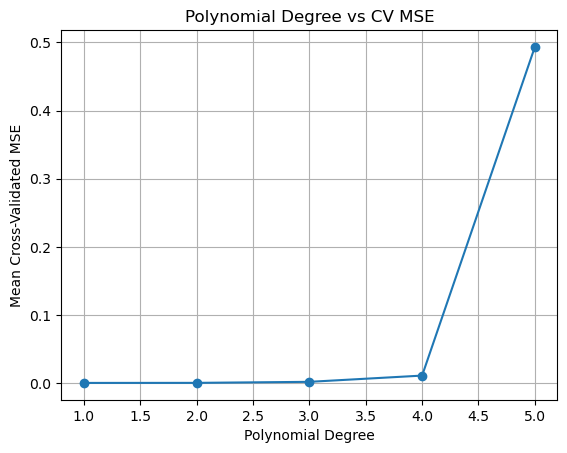


 Best Polynomial Degree: 1


In [106]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
import numpy as np
import matplotlib.pyplot as plt

# Define X and y
X = Stock_close_FF_fltr[['MKT_prm', 'SMB', 'HML', 'RMW', 'CMA']]
y = Stock_close_FF_fltr['exs_rtn_nvda']

# Range of degrees to test
degrees = range(1, 6)
mean_mse_scores = []

# Loop through each degree
for degree in degrees:
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_poly = poly.fit_transform(X)
    
    model = LinearRegression()
    mse_scores = cross_val_score(model, X_poly, y, 
                                 scoring='neg_mean_squared_error', cv=5)
    
    mean_mse = -np.mean(mse_scores)  # Convert to positive MSE
    mean_mse_scores.append(mean_mse)
    print(f"Degree {degree} - Mean CV MSE: {mean_mse:.6f}")

# Plot the results
plt.plot(degrees, mean_mse_scores, marker='o')
plt.title("Polynomial Degree vs CV MSE")
plt.xlabel("Polynomial Degree")
plt.ylabel("Mean Cross-Validated MSE")
plt.grid(True)
plt.show()

# Best degree
best_degree = degrees[np.argmin(mean_mse_scores)]
print(f"\n Best Polynomial Degree: {best_degree}")


In [107]:
# Step 1: Ensure data is sorted by date
Stock_close_FF_fltr = Stock_close_FF_fltr.sort_index()

# Step 2: Define features and target
X = Stock_close_FF_fltr[['MKT_prm', 'SMB', 'HML', 'RMW', 'CMA']]
y = Stock_close_FF_fltr['exs_rtn_nvda']

# Step 3: Time-aware split (80% train, 20% test)
split_index = int(len(X) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]


In [ ]:
X_train

In [83]:
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, r2_score

# Step 1: Use the same formula, but fit on training data only
formula = 'exs_rtn_nvda ~ MKT_prm + SMB + HML + RMW + CMA'
reg_nvda_ff_train = smf.ols(formula=formula, data=Stock_close_FF_fltr.iloc[:split_index]).fit()

# Step 2: Predict on test set manually using model.predict
X_test_sm = sm.add_constant(X_test)  # statsmodels expects intercept
y_pred_ff = reg_nvda_ff_train.predict(X_test_sm)

# Step 3: Evaluate performance
mse = mean_squared_error(y_test, y_pred_ff)
r2 = r2_score(y_test, y_pred_ff)
n = len(y_test)
p = X_test.shape[1]
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

# Step 4: Print results
print(" Fama-French OLS (Test Data):")
print(f"MSE: {mse}")
print(f"R²: {r2}")
print(f"Adjusted R²: {adj_r2}")


 Fama-French OLS (Test Data):
MSE: 0.0008069856406988837
R²: 0.2566011733376863
Adjusted R²: 0.24149144108845233


## XGBoost

In [84]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

In [85]:
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [2, 3, 4],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0]
}

xgb = XGBRegressor(objective='reg:squarederror', random_state=42)
grid = GridSearchCV(xgb, param_grid=param_grid, scoring='neg_mean_squared_error', cv=5, verbose=1, n_jobs=-1)
grid.fit(X_train, y_train)
best_xgb = grid.best_estimator_

# Step 4: Predict and evaluate
y_pred = best_xgb.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)
n, p = X_test.shape
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

# Step 5: Output
print("\nXGBoost Fama-French Model (Tuned):")
print(f"Best Params: {grid.best_params_}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"R²: {r2}")
print(f"Adjusted R²: {adj_r2}")


Fitting 5 folds for each of 24 candidates, totalling 120 fits

XGBoost Fama-French Model (Tuned):
Best Params: {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 50, 'subsample': 0.8}
MSE: 0.0008019287738968488
RMSE: 0.02831834694852171
R²: 0.26125958193584264
Adjusted R²: 0.24624453278819713


In [ ]:
from xgboost import plot_importance


plt.figure(figsize=(10, 5))
plot_importance(best_xgb, max_num_features=10, importance_type='gain')
plt.title("XGBoost Feature Importance (Gain)")
plt.tight_layout()
plt.show()


- This model perform very bas as compared to the regression model

## Random Forest

In [110]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [111]:
# Step 3: Train Random Forest
rf_ff = RandomForestRegressor(n_estimators=100, random_state=42)
rf_ff.fit(X_train, y_train)

# Step 4: Predict and evaluate
y_pred_rf_ff = rf_ff.predict(X_test)
mse_rf_ff = mean_squared_error(y_test, y_pred_rf_ff)
rmse_rf_ff = mse_rf_ff ** 0.5
r2_rf_ff = r2_score(y_test, y_pred_rf_ff)
n, p = X_test.shape
adj_r2_rf_ff = 1 - (1 - r2_rf_ff) * (n - 1) / (n - p - 1)

# Step 5: Output
print("\n📊 Random Forest (Fama-French Model):")
print(f"MSE: {mse_rf_ff}")
print(f"RMSE: {rmse_rf_ff}")
print(f"R²: {r2_rf_ff}")
print(f"Adjusted R²: {adj_r2_rf_ff}")


📊 Random Forest (Fama-French Model):
MSE: 0.0008602859323180067
RMSE: 0.029330631297638424
R²: 0.207500703326721
Adjusted R²: 0.19139299404474386
